In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
 
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("=" * 55)
print("STEP 1 — DATA SETUP & EDA")
print("=" * 55)
 
df = pd.read_csv('fertility.csv')
 
print("\n---- Shape ----")
print(df.shape)
 
print("\n---- Info ----")
df.info()

print("\n---- Describe ----")
print(df.describe())
 
print("\n---- Target Distribution ----")
print(df['output'].value_counts())

STEP 1 — DATA SETUP & EDA

---- Shape ----
(100, 10)

---- Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   season                 100 non-null    float64
 1   age                    100 non-null    float64
 2   childish-disease       100 non-null    int64  
 3   trauma                 100 non-null    int64  
 4   surgical-intervention  100 non-null    int64  
 5   fevers                 100 non-null    int64  
 6   alcoholic              100 non-null    float64
 7   smoking                100 non-null    int64  
 8   sitting                100 non-null    float64
 9   output                 100 non-null    object 
dtypes: float64(4), int64(5), object(1)
memory usage: 7.9+ KB

---- Describe ----
           season         age  childish-disease      trauma  \
count  100.000000  100.000000        100.000000  100.00000

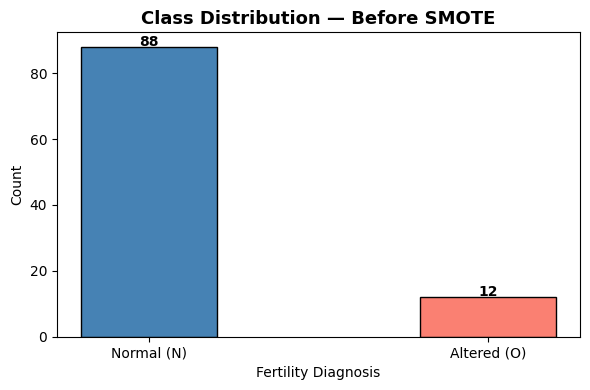

Saved: graph1_class_distribution_before_smote.png

── Feature Variances (justifies PCA — low-variance features add noise) ──
season                   0.6348
age                      0.0147
childish-disease         0.1142
trauma                   0.2489
surgical-intervention    0.2524
fevers                   0.3373
alcoholic                0.0281
smoking                  0.6540
sitting                  0.0347
dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['output'].value_counts()
ax.bar(counts.index, counts.values,
       color=['steelblue', 'salmon'], edgecolor='black', width=0.4)
ax.set_title('Class Distribution — Before SMOTE', fontsize=13, fontweight='bold')
ax.set_xlabel('Fertility Diagnosis')
ax.set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.3, str(val), ha='center', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Normal (N)', 'Altered (O)'])
plt.tight_layout()
plt.savefig('graph1_class_distribution_before_smote.png', dpi=150)
plt.show()
print("Saved: graph1_class_distribution_before_smote.png")
 
# --- Print feature variances (justify PCA) ---
print("\n── Feature Variances (justifies PCA — low-variance features add noise) ---")
print(df.drop(columns='output').var().round(4))
 

In [ ]:
print("\n" + "=" * 55)
print("STEP 2 — DATA PREPROCESSING")
print("=" * 55)
 
# Missing values check
print("\n--- Missing Values ---")
print(df.isnull().sum())    


STEP 2 — DATA PREPROCESSING

── Missing Values ──
season                   0
age                      0
childish-disease         0
trauma                   0
surgical-intervention    0
fevers                   0
alcoholic                0
smoking                  0
sitting                  0
output                   0
dtype: int64


In [10]:
# Encode target: N → 0, O → 1
le_target = LabelEncoder()
df['output'] = le_target.fit_transform(df['output'])   # N=0, O=1
print("\n--- Target Encoding: N → 0, O (Altered) → 1 ---")
print(df['output'].value_counts())

# Encode 'season' column using LabelEncoder
le_season = LabelEncoder()
df['season'] = le_season.fit_transform(df['season'])
print("\n--- Season encoded with LabelEncoder ---")
print("Unique season values after encoding:", df['season'].unique()) 


--- Target Encoding: N → 0, O (Altered) → 1 ---
output
0    88
1    12
Name: count, dtype: int64

--- Season encoded with LabelEncoder ---
Unique season values after encoding: [1 3 0 2]


In [12]:
# Features and target
X = df.drop(columns='output')
y = df['output']


# --- SPLIT FIRST — before any scaling ---
# The scaler must only learn from training data.
# If we scaled before splitting, the scaler would see val/test min & max
# — that is data leakage. So: split first, scale after.
 
# Step 1: split off 40% as a temporary hold-out (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,          # 40% goes to temp (will become val + test)
    random_state=42,
    stratify=y
)
# Step 2: split the 40% temp evenly → 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # 50% of 40% = 20% of total
    random_state=42,
    stratify=y_temp
)
print(f"\n--- 60 / 20 / 20 Train / Validation / Test Split ---")
print(f"  Train      samples : {X_train.shape[0]}  (60%)")
print(f"  Validation samples : {X_val.shape[0]}   (20%)")
print(f"  Test       samples : {X_test.shape[0]}   (20%)")
 


--- 60 / 20 / 20 Train / Validation / Test Split ---
  Train      samples : 60  (60%)
  Validation samples : 20   (20%)
  Test       samples : 20   (20%)


In [13]:
# --- SCALE AFTER SPLITTING — fit on train only ---
# fit_transform on train : scaler LEARNS the min & max from training data
# transform on val/test  : applies those SAME min & max values (no re-learning)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)   # learn min/max FROM train only
X_val   = scaler.transform(X_val)         # apply same scale to val
X_test  = scaler.transform(X_test)        # apply same scale to test
print("\n--- MinMaxScaler: fit on train only, transformed val and test ---")
 


--- MinMaxScaler: fit on train only, transformed val and test ---



── PCA (95% variance threshold) ---
  Original features  : 9
  PCA components kept: 8
  Explained variance ratios: [0.251 0.221 0.157 0.122 0.092 0.061 0.045 0.03 ]
  Total variance retained  : 0.9797


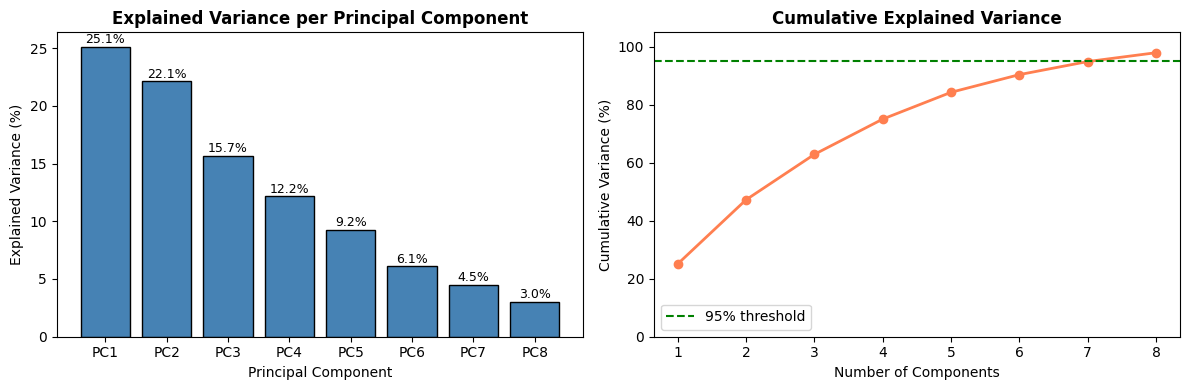

Saved: graph_scree_plot.png (Unique Graph — Scree Plot)


In [14]:
# --- PCA — fit ONLY on train, transform all three sets ---
# n_components=0.95 keeps enough components to explain 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)   # learn PCA from train only
X_val_pca   = pca.transform(X_val)         # apply to validation
X_test_pca  = pca.transform(X_test)        # apply to test
 
print(f"\n── PCA (95% variance threshold) ---")
print(f"  Original features  : {X_train.shape[1]}")
print(f"  PCA components kept: {pca.n_components_}")
print(f"  Explained variance ratios: "
      f"{np.round(pca.explained_variance_ratio_, 3)}")
print(f"  Total variance retained  : "
      f"{pca.explained_variance_ratio_.sum():.4f}")
 
# --- Unique Graph A : Scree Plot of PCA explained variance ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Left — per-component bar
components = [f"PC{i+1}" for i in range(pca.n_components_)]
axes[0].bar(components, pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='black')
axes[0].set_title('Explained Variance per Principal Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i, v * 100 + 0.3, f"{v*100:.1f}%", ha='center', fontsize=9)
 
# Right — cumulative variance line
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumvar) + 1), cumvar,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(y=95, color='green', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_ylim([0, 105])
axes[1].legend()
axes[1].set_xticks(range(1, len(cumvar) + 1))
 
plt.tight_layout()
plt.savefig('graph_scree_plot.png', dpi=150)
plt.show()
print("Saved: graph_scree_plot.png (Unique Graph — Scree Plot)")


STEP 3 — HANDLING CLASS IMBALANCE

── Class counts BEFORE SMOTE (training set) ──
  Normal (0): 53
  Altered (1): 7

── Class counts AFTER SMOTE (training set) ──
  Normal (0): 53
  Altered (1): 53


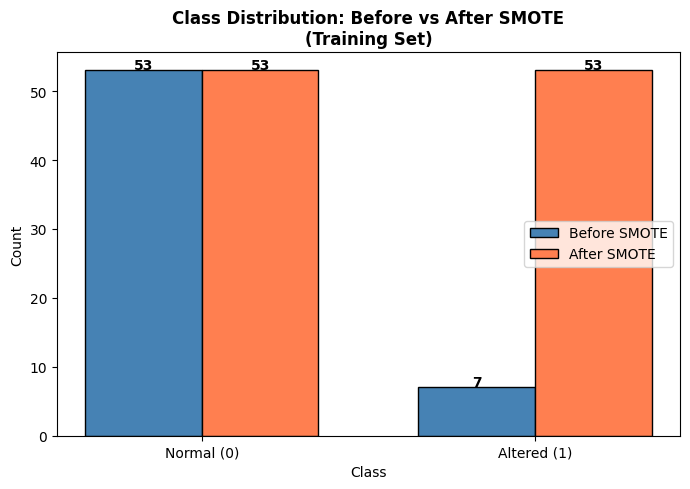

Saved: graph2_smote_distribution.png


In [15]:
print("\n" + "=" * 55)
print("STEP 3 — HANDLING CLASS IMBALANCE")
print("=" * 55)
 
print("\n── Class counts BEFORE SMOTE (training set) ──")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Normal' if u == 0 else 'Altered'
    print(f"  {label} ({u}): {c}")
 
# Apply SMOTE AFTER PCA — only on PCA-transformed TRAINING data
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train_pca, y_train)
 
print("\n── Class counts AFTER SMOTE (training set) ──")
unique_s, counts_s = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique_s, counts_s):
    label = 'Normal' if u == 0 else 'Altered'
    print(f"  {label} ({u}): {c}")
 
# ── Graph 2 (Mandatory) : Class distribution Before vs After SMOTE ──
labels = ['Normal (0)', 'Altered (1)']
before_counts = [counts[0], counts[1]]
after_counts  = [counts_s[0], counts_s[1]]
 
x = np.arange(len(labels))
width = 0.35
 
fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, before_counts, width, label='Before SMOTE',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, after_counts,  width, label='After SMOTE',
               color='coral', edgecolor='black')
 
ax.set_title('Class Distribution: Before vs After SMOTE\n(Training Set)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
 
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', fontweight='bold')
 
plt.tight_layout()
plt.savefig('graph2_smote_distribution.png', dpi=150)
plt.show()
print("Saved: graph2_smote_distribution.png")
 

In [ ]:
print("\n" + "=" * 55)
print("STEP 4 — MODEL DEVELOPMENT")
print("=" * 55)
 
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01]
}
 
grid_search = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
 
print("\n--- Running GridSearchCV for SVC (RBF kernel) ---")
grid_search.fit(X_train_smote, y_train_smote)
 
best_model = grid_search.best_estimator_
print(f"\n--- Best Hyperparameters ---")
print(f"  C     : {grid_search.best_params_['C']}")
print(f"  gamma : {grid_search.best_params_['gamma']}")
print(f"  Best CV F1-score : {grid_search.best_score_:.4f}")
 


STEP 4 — MODEL DEVELOPMENT

── Running GridSearchCV for SVC (RBF kernel) ──
Fitting 5 folds for each of 12 candidates, totalling 60 fits

── Best Hyperparameters ──
  C     : 10
  gamma : scale
  Best CV F1-score : 0.9731



STEP 5 — MODEL EVALUATION (Best RBF SVM)

── [Validation Set] Classification Report ──
              precision    recall  f1-score   support

  Normal (0)       0.88      0.88      0.88        17
 Altered (1)       0.33      0.33      0.33         3

    accuracy                           0.80        20
   macro avg       0.61      0.61      0.61        20
weighted avg       0.80      0.80      0.80        20

  Validation Accuracy: 0.8000

── [Test Set — Final] Classification Report ──
              precision    recall  f1-score   support

  Normal (0)       0.89      0.94      0.92        18
 Altered (1)       0.00      0.00      0.00         2

    accuracy                           0.85        20
   macro avg       0.45      0.47      0.46        20
weighted avg       0.81      0.85      0.83        20

  Test Accuracy: 0.8500


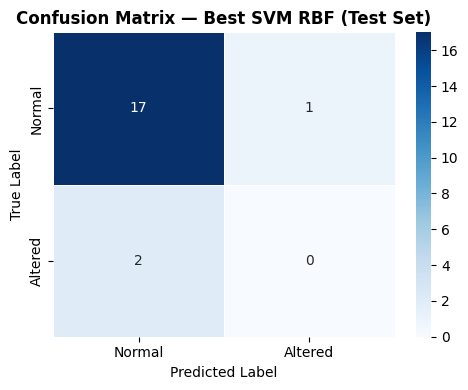

Saved: graph3_confusion_matrix_rbf.png


In [17]:
print("\n" + "=" * 55)
print("STEP 5 — MODEL EVALUATION (Best RBF SVM)")
print("=" * 55)
 
# ── 5a: Validation Set Performance ──
y_pred_val = best_model.predict(X_val_pca)
val_accuracy = best_model.score(X_val_pca, y_val)
 
print("\n── [Validation Set] Classification Report ──")
print(classification_report(y_val, y_pred_val,
                             target_names=['Normal (0)', 'Altered (1)']))
print(f"  Validation Accuracy: {val_accuracy:.4f}")
 
# ── 5b: Test Set Performance (final evaluation) ──
y_pred_rbf = best_model.predict(X_test_pca)
rbf_accuracy = best_model.score(X_test_pca, y_test)
 
print("\n── [Test Set — Final] Classification Report ──")
print(classification_report(y_test, y_pred_rbf,
                             target_names=['Normal (0)', 'Altered (1)']))
print(f"  Test Accuracy: {rbf_accuracy:.4f}")
 
# ── Graph 3 (Mandatory) : Confusion Matrix on Test Set ──
cm = confusion_matrix(y_test, y_pred_rbf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Altered'],
            yticklabels=['Normal', 'Altered'],
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Best SVM RBF (Test Set)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('graph3_confusion_matrix_rbf.png', dpi=150)
plt.show()
print("Saved: graph3_confusion_matrix_rbf.png")



STEP 6 — MODEL COMPARISON: Linear vs RBF SVM

── Linear SVM — Test Set ──
              precision    recall  f1-score   support

  Normal (0)       0.93      0.72      0.81        18
 Altered (1)       0.17      0.50      0.25         2

    accuracy                           0.70        20
   macro avg       0.55      0.61      0.53        20
weighted avg       0.85      0.70      0.76        20

  Val  Accuracy (Linear) : 0.7000
  Test Accuracy (Linear) : 0.7000
  Val  Accuracy (RBF)    : 0.8000
  Test Accuracy (RBF)    : 0.8500


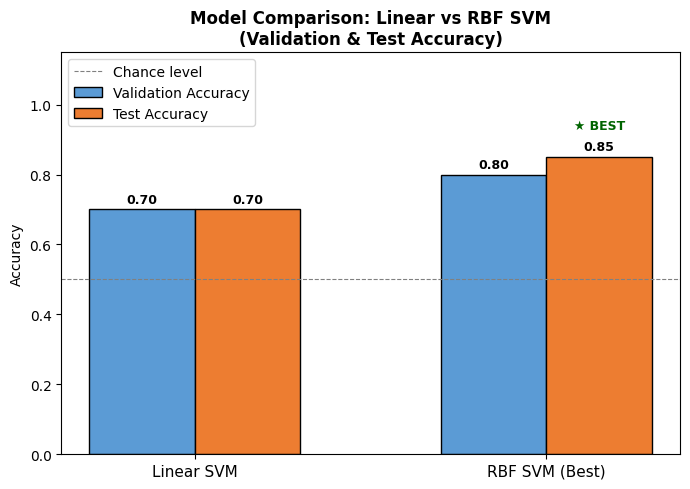

Saved: graph4_linear_vs_rbf_accuracy.png


In [20]:
print("\n" + "=" * 55)
print("STEP 6 — MODEL COMPARISON: Linear vs RBF SVM")
print("=" * 55)
 
svm_linear = SVC(kernel='linear', probability=True, random_state=42, C=1.0)
svm_linear.fit(X_train_smote, y_train_smote)
 
# Validation performance for linear
y_pred_linear_val = svm_linear.predict(X_val_pca)
linear_val_acc    = svm_linear.score(X_val_pca, y_val)
 
# Test performance for linear
y_pred_linear     = svm_linear.predict(X_test_pca)
linear_accuracy   = svm_linear.score(X_test_pca, y_test)
 
print(f"\n── Linear SVM — Test Set ──")
print(classification_report(y_test, y_pred_linear,
                             target_names=['Normal (0)', 'Altered (1)']))
print(f"  Val  Accuracy (Linear) : {linear_val_acc:.4f}")
print(f"  Test Accuracy (Linear) : {linear_accuracy:.4f}")
print(f"  Val  Accuracy (RBF)    : {val_accuracy:.4f}")
print(f"  Test Accuracy (RBF)    : {rbf_accuracy:.4f}")
 
# ── Unique Graph B : Grouped bar — Val & Test accuracy for both models ──
x        = np.arange(2)       # two model positions
width    = 0.30
val_accs  = [linear_val_acc,  val_accuracy]
test_accs = [linear_accuracy, rbf_accuracy]
labels    = ['Linear SVM', 'RBF SVM (Best)']
 
fig, ax = plt.subplots(figsize=(7, 5))
bars_val  = ax.bar(x - width/2, val_accs,  width, label='Validation Accuracy',
                   color='#5b9bd5', edgecolor='black')
bars_test = ax.bar(x + width/2, test_accs, width, label='Test Accuracy',
                   color='#ed7d31', edgecolor='black')
 
ax.set_title('Model Comparison: Linear vs RBF SVM\n(Validation & Test Accuracy)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1.15])
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, label='Chance level')
ax.legend()
 
for bar in bars_val + bars_test:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha='center', fontsize=9, fontweight='bold')
 
# Mark the best test model
best_test_idx = test_accs.index(max(test_accs))
ax.text(x[best_test_idx] + width/2, max(test_accs) + 0.08,
        "★ BEST", ha='center', fontsize=9, color='darkgreen', fontweight='bold')
 
plt.tight_layout()
plt.savefig('graph4_linear_vs_rbf_accuracy.png', dpi=150)
plt.show()
print("Saved: graph4_linear_vs_rbf_accuracy.png")



STEP 6b — SMOTE vs NO SMOTE COMPARISON

── Without SMOTE — Validation Set ──
              precision    recall  f1-score   support

  Normal (0)       0.88      0.88      0.88        17
 Altered (1)       0.33      0.33      0.33         3

    accuracy                           0.80        20
   macro avg       0.61      0.61      0.61        20
weighted avg       0.80      0.80      0.80        20


── Without SMOTE — Test Set ──
              precision    recall  f1-score   support

  Normal (0)       0.89      0.89      0.89        18
 Altered (1)       0.00      0.00      0.00         2

    accuracy                           0.80        20
   macro avg       0.44      0.44      0.44        20
weighted avg       0.80      0.80      0.80        20


── With SMOTE — already computed above ──
              precision    recall  f1-score   support

  Normal (0)       0.89      0.94      0.92        18
 Altered (1)       0.00      0.00      0.00         2

    accuracy                 

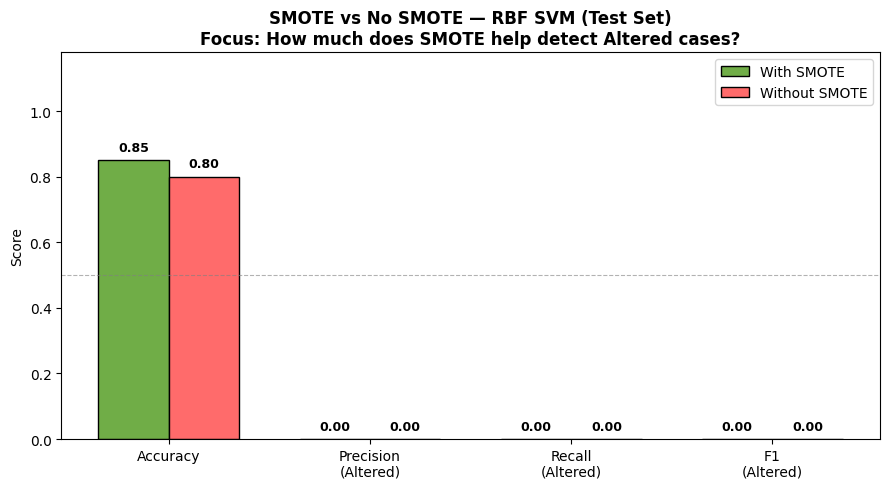

Saved: graph5_smote_vs_nosmote.png


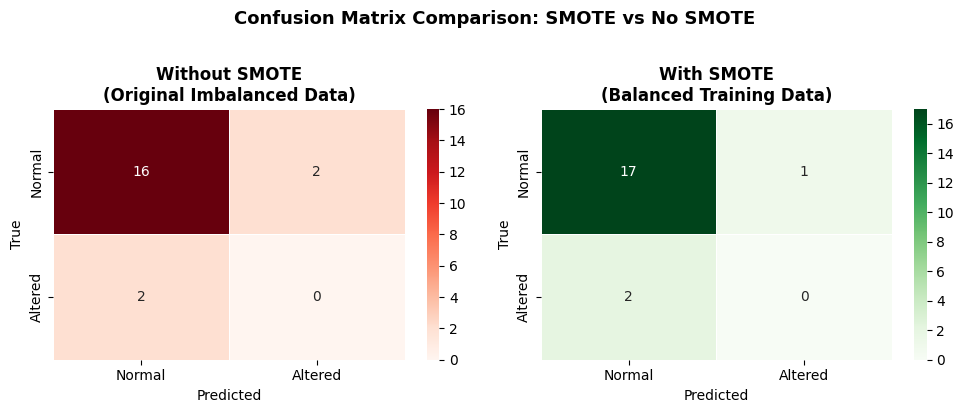

Saved: graph6_confusion_smote_vs_nosmote.png


In [21]:
print("\n" + "=" * 55)
print("STEP 6b — SMOTE vs NO SMOTE COMPARISON")
print("=" * 55)
 
# Train on original PCA-transformed training data — no SMOTE applied
svm_no_smote = SVC(kernel='rbf', probability=True,
                   C=grid_search.best_params_['C'],
                   gamma=grid_search.best_params_['gamma'],
                   random_state=42)
svm_no_smote.fit(X_train_pca, y_train)   # X_train_pca = original, imbalanced
 
# Evaluate no-SMOTE model on validation and test
y_pred_no_smote_val  = svm_no_smote.predict(X_val_pca)
y_pred_no_smote_test = svm_no_smote.predict(X_test_pca)
 
no_smote_val_acc  = svm_no_smote.score(X_val_pca,  y_val)
no_smote_test_acc = svm_no_smote.score(X_test_pca, y_test)
 
print("\n── Without SMOTE — Validation Set ──")
print(classification_report(y_val, y_pred_no_smote_val,
                             target_names=['Normal (0)', 'Altered (1)'],
                             zero_division=0))
 
print("\n── Without SMOTE — Test Set ──")
print(classification_report(y_test, y_pred_no_smote_test,
                             target_names=['Normal (0)', 'Altered (1)'],
                             zero_division=0))
 
print("\n── With SMOTE — already computed above ──")
print(classification_report(y_test, y_pred_rbf,
                             target_names=['Normal (0)', 'Altered (1)'],
                             zero_division=0))
 
# ── Extract per-class metrics for the comparison graph ──
from sklearn.metrics import precision_score, recall_score, f1_score
 
# With SMOTE (on test set)
smote_acc      = rbf_accuracy
smote_prec_alt = precision_score(y_test, y_pred_rbf,      pos_label=1, zero_division=0)
smote_rec_alt  = recall_score(   y_test, y_pred_rbf,      pos_label=1, zero_division=0)
smote_f1_alt   = f1_score(       y_test, y_pred_rbf,      pos_label=1, zero_division=0)
 
# Without SMOTE (on test set)
nosmote_acc      = no_smote_test_acc
nosmote_prec_alt = precision_score(y_test, y_pred_no_smote_test, pos_label=1, zero_division=0)
nosmote_rec_alt  = recall_score(   y_test, y_pred_no_smote_test, pos_label=1, zero_division=0)
nosmote_f1_alt   = f1_score(       y_test, y_pred_no_smote_test, pos_label=1, zero_division=0)
 
print(f"\n── Head-to-Head (Test Set, Altered class focus) ──")
print(f"  {'Metric':<30} {'With SMOTE':>12} {'Without SMOTE':>14}")
print(f"  {'-'*56}")
print(f"  {'Overall Accuracy':<30} {smote_acc:>12.4f} {nosmote_acc:>14.4f}")
print(f"  {'Precision (Altered)':<30} {smote_prec_alt:>12.4f} {nosmote_prec_alt:>14.4f}")
print(f"  {'Recall    (Altered)':<30} {smote_rec_alt:>12.4f} {nosmote_rec_alt:>14.4f}")
print(f"  {'F1-Score  (Altered)':<30} {smote_f1_alt:>12.4f} {nosmote_f1_alt:>14.4f}")
 
# ── Graph 5 : Grouped bar — SMOTE vs No SMOTE across 4 metrics ──
metrics      = ['Accuracy', 'Precision\n(Altered)', 'Recall\n(Altered)', 'F1\n(Altered)']
smote_vals   = [smote_acc,   smote_prec_alt,   smote_rec_alt,   smote_f1_alt]
nosmote_vals = [nosmote_acc, nosmote_prec_alt, nosmote_rec_alt, nosmote_f1_alt]
 
x     = np.arange(len(metrics))
width = 0.35
 
fig, ax = plt.subplots(figsize=(9, 5))
bars_smote   = ax.bar(x - width/2, smote_vals,   width,
                      label='With SMOTE',    color='#70ad47', edgecolor='black')
bars_nosmote = ax.bar(x + width/2, nosmote_vals, width,
                      label='Without SMOTE', color='#ff6b6b', edgecolor='black')
 
ax.set_title('SMOTE vs No SMOTE — RBF SVM (Test Set)\n'
             'Focus: How much does SMOTE help detect Altered cases?',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0, 1.18])
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.legend(fontsize=10)
 
# Annotate each bar with its value
for bar in list(bars_smote) + list(bars_nosmote):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.2f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.savefig('graph5_smote_vs_nosmote.png', dpi=150)
plt.show()
print("Saved: graph5_smote_vs_nosmote.png")
 
# ── Confusion matrices side by side: SMOTE vs No SMOTE ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
cm_smote   = confusion_matrix(y_test, y_pred_rbf)
cm_nosmote = confusion_matrix(y_test, y_pred_no_smote_test)
 
sns.heatmap(cm_nosmote, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Altered'],
            yticklabels=['Normal', 'Altered'],
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Without SMOTE\n(Original Imbalanced Data)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
 
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Altered'],
            yticklabels=['Normal', 'Altered'],
            linewidths=0.5, ax=axes[1])
axes[1].set_title('With SMOTE\n(Balanced Training Data)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
 
plt.suptitle('Confusion Matrix Comparison: SMOTE vs No SMOTE',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph6_confusion_smote_vs_nosmote.png', dpi=150)
plt.show()
print("Saved: graph6_confusion_smote_vs_nosmote.png")
 

In [22]:
print("\n" + "=" * 55)
print("FINAL SUMMARY — APPROACH 3: SVM + PCA")
print("=" * 55)
print(f"  Split                    : 60% Train / 20% Val / 20% Test")
print(f"  Train samples            : {X_train.shape[0]}")
print(f"  Validation samples       : {X_val.shape[0]}")
print(f"  Test samples             : {X_test.shape[0]}")
print(f"  PCA components retained  : {pca.n_components_} (from {X.shape[1]})")
print(f"  Total variance retained  : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Best SVM params          : C={grid_search.best_params_['C']}, "
      f"gamma={grid_search.best_params_['gamma']}")
print(f"  Linear SVM — Val/Test    : {linear_val_acc:.4f} / {linear_accuracy:.4f}")
print(f"  RBF    SVM — Val/Test    : {val_accuracy:.4f} / {rbf_accuracy:.4f}")
print(f"  Better Model             : "
      f"{'RBF' if rbf_accuracy >= linear_accuracy else 'Linear'} SVM")
print(f"  SMOTE Recall (Altered)   : {smote_rec_alt:.4f}  |  "
      f"No-SMOTE Recall: {nosmote_rec_alt:.4f}")
print("=" * 55)
print("\nAll graphs saved successfully.")
print("Graphs produced:")
print("  [Mandatory 1] graph1_class_distribution_before_smote.png")
print("  [Mandatory 2] graph2_smote_distribution.png")
print("  [Mandatory 3] graph3_confusion_matrix_rbf.png")
print("  [Unique A   ] graph_scree_plot.png")
print("  [Unique B   ] graph4_linear_vs_rbf_accuracy.png")
print("  [Extra 1    ] graph5_smote_vs_nosmote.png")
print("  [Extra 2    ] graph6_confusion_smote_vs_nosmote.png")


FINAL SUMMARY — APPROACH 3: SVM + PCA
  Split                    : 60% Train / 20% Val / 20% Test
  Train samples            : 60
  Validation samples       : 20
  Test samples             : 20
  PCA components retained  : 8 (from 9)
  Total variance retained  : 97.97%
  Best SVM params          : C=10, gamma=scale
  Linear SVM — Val/Test    : 0.7000 / 0.7000
  RBF    SVM — Val/Test    : 0.8000 / 0.8500
  Better Model             : RBF SVM
  SMOTE Recall (Altered)   : 0.0000  |  No-SMOTE Recall: 0.0000

All graphs saved successfully.
Graphs produced:
  [Mandatory 1] graph1_class_distribution_before_smote.png
  [Mandatory 2] graph2_smote_distribution.png
  [Mandatory 3] graph3_confusion_matrix_rbf.png
  [Unique A   ] graph_scree_plot.png
  [Unique B   ] graph4_linear_vs_rbf_accuracy.png
  [Extra 1    ] graph5_smote_vs_nosmote.png
  [Extra 2    ] graph6_confusion_smote_vs_nosmote.png
